In [ ]:
# importing all necessary libararies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
deliveries = pd.read_csv("/content/deliveries.csv")

In [ ]:
matches = pd.read_csv("/content/matches.csv")

In [ ]:
matches.shape

(1095, 20)

In [ ]:
deliveries.shape

(260920, 17)

In [ ]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [ ]:
matches.isnull().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


In [ ]:
# removing method column because few matches uses D/L method
matches.drop(columns=['method'], inplace=True)

In [ ]:
deliveries.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batter,0
bowler,0
non_striker,0
batsman_runs,0


In [ ]:
# now we are merging both the tables
df = deliveries.merge(matches, left_on='match_id', right_on='id')

In [ ]:

df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen


In [ ]:
df.shape

(260920, 36)

In [ ]:
# now we will do feature engineering properly
# Total runs in each ball (bat + extras)
df['total_runs'] = df['batsman_runs'] + df['extra_runs']

In [ ]:
# Correct ball number calculation (since over starts from 0)
df['ball_number'] = (df['over'] * 6) + df['ball']

In [ ]:
# Mark boundary (4 or 6)
df['is_boundary'] = df['batsman_runs'].apply(lambda x: 1 if x in [4,6] else 0)

In [ ]:
# Mark dot ball (no runs scored)
df['is_dot'] = df['total_runs'].apply(lambda x: 1 if x == 0 else 0)

In [ ]:
# Mark wicket (1 = wicket, 0 = no wicket)
df['dismissal'] = df['is_wicket']

In [ ]:
df.shape

(260920, 40)

In [ ]:
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,result_margin,target_runs,target_overs,super_over,umpire1,umpire2,ball_number,is_boundary,is_dot,dismissal
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen,1,0,0,0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen,2,0,1,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen,3,0,0,0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen,4,0,1,0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen,5,0,1,0


In [ ]:
# now we will start analysis for our dataset
top_batsman = df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

top_batsman

,batsman_runs
batter,
V Kohli,8014
S Dhawan,6769
RG Sharma,6630
DA Warner,6567
SK Raina,5536
MS Dhoni,5243
AB de Villiers,5181
CH Gayle,4997
RV Uthappa,4954


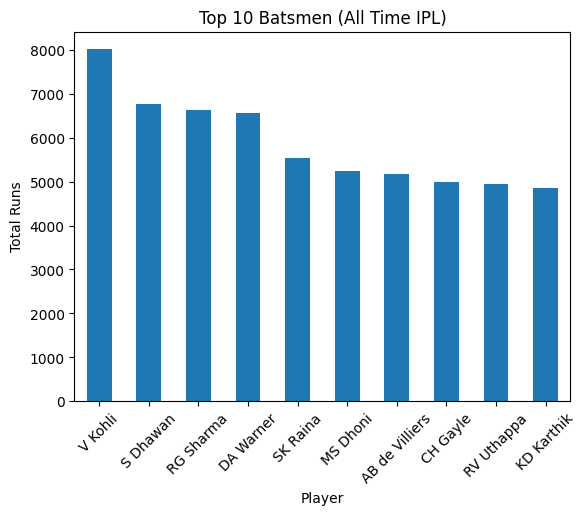

In [ ]:
top_batsman.plot(kind='bar')

plt.title("Top 10 Batsmen (All Time IPL)")
plt.xlabel("Player")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.show()

In [ ]:
top_teams = df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)

top_teams

,total_runs
batting_team,
Mumbai Indians,42176
Kolkata Knight Riders,39331
Chennai Super Kings,38629
Royal Challengers Bangalore,37692
Rajasthan Royals,34747
Kings XI Punjab,30064
Sunrisers Hyderabad,29071
Delhi Daredevils,24296
Delhi Capitals,14900


here we can see inconsistency in the result of top teams because the name of teams changes over the years so we have to standarize it

In [ ]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

df['batting_team'] = df['batting_team'].replace(team_mapping)
df['bowling_team'] = df['bowling_team'].replace(team_mapping)

In [ ]:
top_teams = df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
top_teams

,total_runs
batting_team,
Mumbai Indians,42176
Royal Challengers Bangalore,40622
Punjab Kings,39600
Kolkata Knight Riders,39331
Delhi Capitals,39196
Chennai Super Kings,38629
Rajasthan Royals,34747
Sunrisers Hyderabad,29071
Deccan Chargers,11463


Now we have to calculate strike rate of players which is runs/balls * 100

In [ ]:
# total runs by player
runs = df.groupby('batter')['batsman_runs'].sum()

# total balls faced (excluding wides)
balls = df[df['extras_type'] != 'wides'].groupby('batter')['ball'].count()

# strike rate
strike_rate = (runs / balls) * 100

# top players (filter min runs to avoid noise)
strike_rate = strike_rate[runs > 2000].sort_values(ascending=False).head(10)

strike_rate


,0
batter,
AD Russell,174.841883
GJ Maxwell,156.698700
V Sehwag,155.441595
AB de Villiers,151.890941
CH Gayle,149.342499
RR Pant,148.848758
KA Pollard,147.574066
JC Buttler,147.448560
HH Pandya,145.715929


Strike rate alone can be misleading because some players face fewer balls and achieve high strike rates. To ensure reliable comparison, we filter players based on minimum runs so that only consistent performers are considered.

In [ ]:
# create dataframe
sr_df = pd.DataFrame({
    'runs': runs,
    'balls': balls
})

# calculate strike rate
sr_df['strike_rate'] = (sr_df['runs'] / sr_df['balls']) * 100

# filter serious players
sr_df = sr_df[sr_df['runs'] > 2000]

# sort
sr_df = sr_df.sort_values(by='strike_rate', ascending=False).head(10)

sr_df

,runs,balls,strike_rate
batter,,,
AD Russell,2488,1423,174.841883
GJ Maxwell,2772,1769,156.698700
V Sehwag,2728,1755,155.441595
AB de Villiers,5181,3411,151.890941
CH Gayle,4997,3346,149.342499
RR Pant,3297,2215,148.848758
KA Pollard,3437,2329,147.574066
JC Buttler,3583,2430,147.448560
HH Pandya,2534,1739,145.715929


Now Bowler Analysis

In [ ]:
dot_balls = df.groupby('bowler')['is_dot'].sum()
total_balls = df.groupby('bowler')['ball'].count()

dot_percentage = (dot_balls / total_balls) * 100

dot_percentage = dot_percentage[total_balls > 500].sort_values(ascending=False).head(10)

dot_percentage

,0
bowler,
DW Steyn,44.653812
MM Patel,42.691751
JC Archer,42.553191
DE Bollinger,42.333333
S Sreesanth,42.133052
RJ Harris,42.080925
M Morkel,41.671572
JR Hazlewood,41.639871
DP Nannes,41.364296


FEATURE 1: Player Comparison

In [ ]:
def player_comparison(player1, player2):

    players = [player1, player2]

    data = df[df['batter'].isin(players)]

    runs = data.groupby('batter')['batsman_runs'].sum()
    balls = data[data['extras_type'] != 'wides'].groupby('batter')['ball'].count()

    sr = (runs / balls) * 100

    result = pd.DataFrame({
        'Runs': runs,
        'Balls': balls,
        'Strike Rate': sr
    })

    return result

In [ ]:
player_comparison('V Kohli', 'AB de Villiers')

,Runs,Balls,Strike Rate
batter,,,
AB de Villiers,5181,3411,151.890941
V Kohli,8014,6069,132.048113


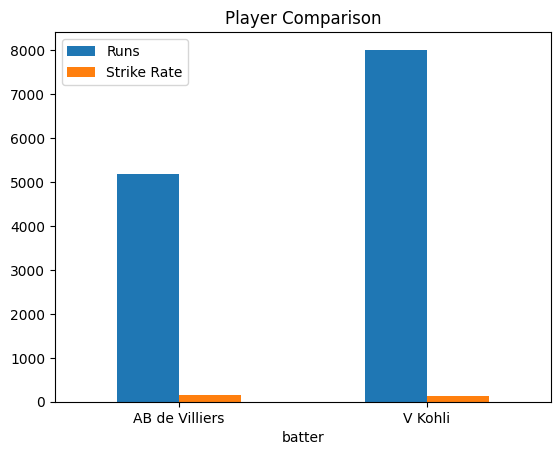

In [ ]:
result = player_comparison('V Kohli', 'AB de Villiers')

result[['Runs','Strike Rate']].plot(kind='bar')
plt.title("Player Comparison")
plt.xticks(rotation=0)
plt.show()

FEATURE 2: Death Overs Analysis

In [ ]:
death_df = df[df['over'] >= 15]

death_runs = death_df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

death_runs

,batsman_runs
batter,
MS Dhoni,3292
KA Pollard,2032
KD Karthik,1904
AB de Villiers,1868
RA Jadeja,1680
RG Sharma,1513
V Kohli,1469
AD Russell,1324
DA Miller,1298


Strike rate in death overs


In [ ]:
death_df = df[df['over'] >= 15]

runs = death_df.groupby('batter')['batsman_runs'].sum()
balls = death_df[death_df['extras_type'] != 'wides'].groupby('batter')['ball'].count()

death_sr = (runs / balls) * 100

death_sr = death_sr[runs > 500].sort_values(ascending=False).head(10)

death_sr

,0
batter,
AB de Villiers,222.911695
CH Gayle,204.577465
RR Pant,203.303965
JC Buttler,197.350993
AD Russell,194.419971
TH David,191.489362
SV Samson,190.243902
V Kohli,187.372449
SO Hetmyer,181.006865


FEATURE 3: Powerplay Analysis

In [ ]:
pp_df = df[df['over'] < 6]

pp_runs = pp_df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)

pp_runs

,total_runs
batting_team,
Mumbai Indians,12225
Delhi Capitals,12069
Kolkata Knight Riders,11941
Punjab Kings,11795
Royal Challengers Bangalore,11795
Chennai Super Kings,10991
Rajasthan Royals,10226
Sunrisers Hyderabad,8937
Deccan Chargers,3417


Run Rate in Powerplay

In [ ]:
pp_df = df[df['over'] < 6]

runs = pp_df.groupby('batting_team')['total_runs'].sum()
balls = pp_df.groupby('batting_team')['ball'].count()

pp_rr = (runs / balls) * 6

pp_rr.sort_values(ascending=False)

,0
batting_team,
Gujarat Lions,8.314667
Sunrisers Hyderabad,7.864770
Gujarat Titans,7.772242
Delhi Capitals,7.674226
Punjab Kings,7.665728
Kochi Tuskers Kerala,7.654784
Rising Pune Supergiants,7.623214
Kolkata Knight Riders,7.593641
Lucknow Super Giants,7.591241


FEATURE 4: Match Progression

<Axes: xlabel='ball_number'>

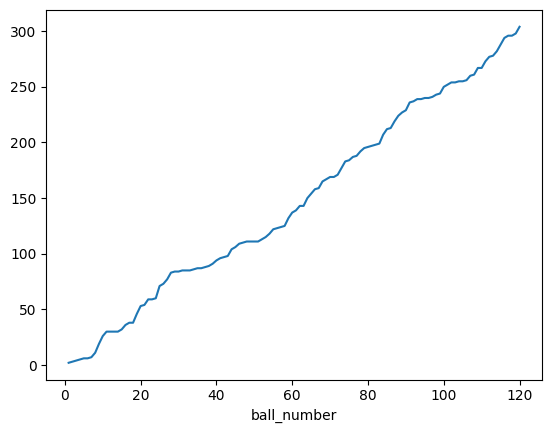

In [ ]:
match_id = 335982  # example match

match_df = df[df['match_id'] == match_id]

progress = match_df.groupby('ball_number')['total_runs'].sum().cumsum()

progress.plot()

Correlation analysis helps identify relationships between match factors such as boundaries, dot balls, and wickets with total runs scored

In [ ]:
match_df = df.groupby(['match_id','inning']).agg({
    'total_runs': 'sum',
    'is_boundary': 'sum',
    'is_dot': 'sum',
    'dismissal': 'sum',
    'ball': 'count'
}).reset_index()

In [ ]:
corr = match_df[['total_runs','is_boundary','is_dot','dismissal','ball']].corr()

corr

,total_runs,is_boundary,is_dot,dismissal,ball
total_runs,1.000000,0.911084,-0.088873,-0.093767,0.651694
is_boundary,0.911084,1.000000,-0.139665,-0.183414,0.417252
is_dot,-0.088873,-0.139665,1.000000,0.576317,0.563412
dismissal,-0.093767,-0.183414,0.576317,1.000000,0.367854
ball,0.651694,0.417252,0.563412,0.367854,1.000000


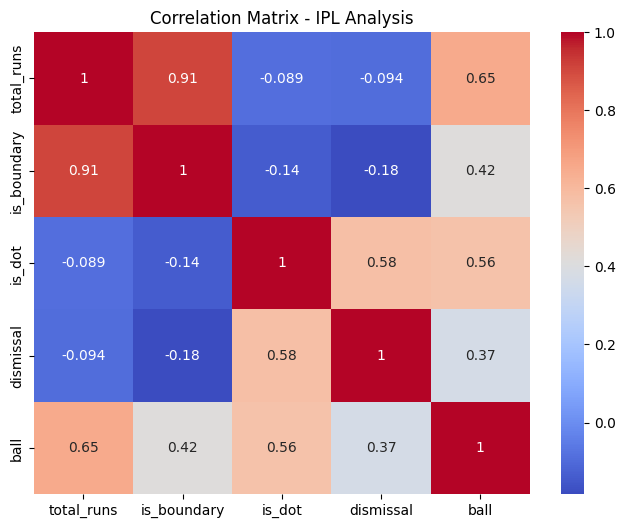

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix - IPL Analysis")
plt.show()

Adding win predictor feature


In [60]:
second_innings = df[df['inning'] == 2].copy()

In [61]:
target = df[df['inning'] == 1].groupby('match_id')['total_runs'].sum().reset_index()

target.rename(columns={'total_runs': 'target'}, inplace=True)

In [62]:
second_innings = second_innings.merge(target, on='match_id')

In [63]:
# runs scored so far
second_innings['runs_scored'] = second_innings.groupby('match_id')['total_runs'].cumsum()

# runs left
second_innings['runs_left'] = second_innings['target'] - second_innings['runs_scored']

# balls left
second_innings['balls_left'] = 120 - second_innings['ball_number']

# wickets fallen
second_innings['wickets'] = second_innings.groupby('match_id')['dismissal'].cumsum()

# wickets left
second_innings['wickets_left'] = 10 - second_innings['wickets']

In [64]:
# current run rate
second_innings['current_run_rate'] = second_innings['runs_scored'] / (120 - second_innings['balls_left']) * 6

# required run rate
second_innings['required_run_rate'] = second_innings['runs_left'] / second_innings['balls_left'] * 6

In [65]:
second_innings['result'] = second_innings.apply(
    lambda row: 1 if row['batting_team'] == row['winner'] else 0, axis=1
)

In [66]:
import numpy as np

# remove invalid rows
second_innings = second_innings[
    (second_innings['balls_left'] > 0) &
    (second_innings['runs_left'] >= 0)
]

# fix infinite values ONLY in required_run_rate
second_innings['required_run_rate'] = second_innings['required_run_rate'].replace([np.inf, -np.inf], np.nan)

# drop rows where required_run_rate is null
second_innings = second_innings.dropna(subset=['required_run_rate'])

In [67]:
second_innings.shape

(124640, 48)

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = second_innings[['runs_left','balls_left','wickets_left','current_run_rate','required_run_rate']]
y = second_innings['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.7355985237483954

In [70]:
model.predict_proba(X_test)[:5]

array([[0.79440792, 0.20559208],
       [0.26808127, 0.73191873],
       [0.38694976, 0.61305024],
       [0.98133419, 0.01866581],
       [0.47492278, 0.52507722]])

In [71]:
def predict_win_probability(runs_left, balls_left, wickets_left, current_run_rate, required_run_rate):

    input_data = pd.DataFrame({
        'runs_left': [runs_left],
        'balls_left': [balls_left],
        'wickets_left': [wickets_left],
        'current_run_rate': [current_run_rate],
        'required_run_rate': [required_run_rate]
    })

    prob = model.predict_proba(input_data)[0]

    return {
        "loss_probability": prob[0],
        "win_probability": prob[1]
    }

In [73]:
def predict_win_probability(runs_left, balls_left, wickets_left, current_run_rate, required_run_rate):

    input_data = pd.DataFrame({
        'runs_left': [runs_left],
        'balls_left': [balls_left],
        'wickets_left': [wickets_left],
        'current_run_rate': [current_run_rate],
        'required_run_rate': [required_run_rate]
    })

    prob = model.predict_proba(input_data)[0]

    return {
        "loss_probability": round(float(prob[0]), 2),
        "win_probability": round(float(prob[1]), 2)
    }

In [74]:
predict_win_probability(
    runs_left=50,
    balls_left=30,
    wickets_left=6,
    current_run_rate=8,
    required_run_rate=10
)

{'loss_probability': 0.6, 'win_probability': 0.4}

match score predictor

In [75]:
first_innings = df[df['inning'] == 1].copy()

In [76]:
# current score
first_innings['current_score'] = first_innings.groupby('match_id')['total_runs'].cumsum()

# balls bowled
first_innings['balls_bowled'] = first_innings['ball_number']

# balls left
first_innings['balls_left'] = 120 - first_innings['balls_bowled']

# wickets fallen
first_innings['wickets'] = first_innings.groupby('match_id')['dismissal'].cumsum()

# run rate
first_innings['run_rate'] = first_innings['current_score'] / first_innings['balls_bowled'] * 6

In [77]:
final_score = first_innings.groupby('match_id')['total_runs'].sum().reset_index()
final_score.rename(columns={'total_runs': 'final_score'}, inplace=True)

first_innings = first_innings.merge(final_score, on='match_id')

In [78]:

# remove invalid rows
first_innings = first_innings[first_innings['balls_left'] > 0]

# fix inf
first_innings['run_rate'] = first_innings['run_rate'].replace([np.inf, -np.inf], np.nan)

# drop nulls
first_innings = first_innings.dropna(subset=['run_rate'])

In [79]:
X = first_innings[['current_score','balls_left','wickets','run_rate']]
y = first_innings['final_score']

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_score = RandomForestRegressor()
model_score.fit(X_train, y_train)

y_pred = model_score.predict(X_test)

mean_absolute_error(y_test, y_pred)

16.58115189358957

In [81]:
def predict_score(current_score, balls_left, wickets, run_rate):

    input_data = pd.DataFrame({
        'current_score': [current_score],
        'balls_left': [balls_left],
        'wickets': [wickets],
        'run_rate': [run_rate]
    })

    pred = model_score.predict(input_data)[0]

    return round(pred, 0)

In [82]:
predict_score(
    current_score=100,
    balls_left=60,
    wickets=3,

  run_rate=10
)

np.float64(184.0)

In [83]:
import pickle

# win prediction model
pickle.dump(model, open('model.pkl', 'wb'))

# score prediction model
pickle.dump(model_score, open('score_model.pkl', 'wb'))